In [73]:
!pip3 install pandas keras tensorflow scikit-learn matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable


In [90]:
# Load the dataset CSV file
# Format: 
#   filename - original stl file name, for tracking
#   d - distance to object in mm
#   o - distance between cameras in mm
#   rx, ry, rz - rotation angles in degrees
#   left - path to left image
#  right - path to right image
dataset_file = './stl_data/base_1_permuted_output/256x256/base_1_permuted.csv'

# Set the image size for loading images & building the neural network model
image_size = (256, 256)

In [91]:
import os
import numpy as np
import pandas as pd
from PIL import Image

# read all rows from the CSV file into a pandas DataFrame
df = pd.read_csv(dataset_file)

# Check if all image files exist and load them into memory
dataset = []
missing_files = []
dataset_path = os.path.dirname(dataset_file)

for _, row in df.iterrows():
    left_path = os.path.join(dataset_path, row["left"])
    right_path = os.path.join(dataset_path, row["right"])

    if not os.path.exists(left_path) or not os.path.exists(right_path):
        missing_files.append((left_path, right_path))
        continue

    left_img = np.asarray(Image.open(left_path).convert("RGB"))
    right_img = np.asarray(Image.open(right_path).convert("RGB"))

    dataset.append({
        "filename": row["filename"],
        "d": row["d"],
        "o": row["o"],
        "rx": row["rx"],
        "ry": row["ry"],
        "rz": row["rz"],
        "image_left": left_img,
        "image_right": right_img,
        "left_path": left_path,
        "right_path": right_path,
    })

if missing_files:
    print(f"{len(missing_files)} missing image files for some rows:", missing_files)
    raise FileNotFoundError("Dataset is corrupt; Some image files are missing. Please check the paths.")

# Extract left and right images and CSV values into numpy arrays
left_images = np.stack([item["image_left"] for item in dataset])
right_images = np.stack([item["image_right"] for item in dataset])
csv_values = np.stack([[item["d"], item["o"], item["rx"], item["ry"], item["rz"]] for item in dataset])

# Print the shapes of the loaded data
print(f"Left images shape: {left_images.shape}")
print(f"Right images shape: {right_images.shape}")
print(f"CSV values shape: {csv_values.shape}")

Left images shape: (245, 256, 256, 3)
Right images shape: (245, 256, 256, 3)
CSV values shape: (245, 5)


In [ ]:
# Build the neural network model, and output the model summary

import tensorflow as tf

input_shape = image_size + (3,)

def image_branch(input_tensor):
    x = tf.keras.layers.Conv2D(32, 3, activation="relu", padding="same")(input_tensor)
    x = tf.keras.layers.MaxPool2D(2)(x)
    x = tf.keras.layers.Flatten()(x)
    x = tf.keras.layers.Dense(128, activation="relu")(x)
    x = tf.keras.layers.Dense(32 * 32 * 8, activation="relu")(x)
    x = tf.keras.layers.Reshape((32, 32, 8))(x)
    x = tf.keras.layers.Conv2D(16, 3, activation="relu", padding="same")(x)
    x = tf.keras.layers.Flatten()(x)
    x = tf.keras.layers.Dense(64, activation="relu")(x)
    return x

input_image_1 = tf.keras.Input(shape=input_shape, name="image_1")
input_image_2 = tf.keras.Input(shape=input_shape, name="image_2")

branch_1 = image_branch(input_image_1)
branch_2 = image_branch(input_image_2)

combined = tf.keras.layers.Concatenate()([branch_1, branch_2])
output_d = tf.keras.layers.Dense(1, activation="linear", name="d")(combined)

model = tf.keras.Model(inputs=[input_image_1, input_image_2], outputs=output_d)
model.compile(optimizer="adam", loss="mse")

model.summary()

Model: "functional_32"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_1             │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_2             │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_128 (Conv2D) │ (None, 256, 256,  │        896 │ image_1[0][0]     │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_130 (Conv2D) │ (None, 256, 256,  │        896 │ image_2[0][0]     │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_64    │ (None, 128, 128,  │          0 │ conv2d_128[0][0]  │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_65    │ (None, 128, 128,  │          0 │ conv2d_130[0][0]  │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_128         │ (None, 524288)    │          0 │ max_pooling2d_64… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_130         │ (None, 524288)    │          0 │ max_pooling2d_65… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_192 (Dense)   │ (None, 128)       │ 67,108,992 │ flatten_128[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_195 (Dense)   │ (None, 128)       │ 67,108,992 │ flatten_130[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_193 (Dense)   │ (None, 8192)      │  1,056,768 │ dense_192[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_196 (Dense)   │ (None, 8192)      │  1,056,768 │ dense_195[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_64          │ (None, 32, 32, 8) │          0 │ dense_193[0][0]   │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_65          │ (None, 32, 32, 8) │          0 │ dense_196[0][0]   │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_129 (Conv2D) │ (None, 32, 32,    │      1,168 │ reshape_64[0][0]  │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_131 (Conv2D) │ (None, 32, 32,    │      1,168 │ reshape_65[0][0]  │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_129         │ (None, 16384)     │          0 │ conv2d_129[0][0]  │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_131         │ (None, 16384)     │          0 │ conv2d_131[0][0]  │
│ (Flatten)           │                   │            │                 

 Total params: 138,433,057 (528.08 MB)

 Trainable params: 138,433,057 (528.08 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the model

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

# normalize image data for training
left_images = left_images.astype("float32") / 255.0
right_images = right_images.astype("float32") / 255.0

# target is the "d" value
y = csv_values[:, 0].astype("float32")

# normalize image data for training
left_images = left_images.astype("float32") / 255.0
right_images = right_images.astype("float32") / 255.0

# target is the "d" value
y = csv_values[:, 0].astype("float32")

X_train_left, X_test_left, X_train_right, X_test_right, y_train, y_test = train_test_split(
    left_images, right_images, y, test_size=0.2, random_state=42, shuffle=True
)

history = model.fit(
    [X_train_left, X_train_right],
    y_train,
    epochs=10,
    batch_size=20,
    validation_split=0.2,
    shuffle=True,
    verbose=1
)

Epoch 1/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 198ms/step - loss: 91049.4375 - val_loss: 155799.7969
Epoch 2/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 177ms/step - loss: 72407.0078 - val_loss: 51982.2695
Epoch 3/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 171ms/step - loss: 56965.0469 - val_loss: 23661.4023
Epoch 4/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 169ms/step - loss: 41659.4492 - val_loss: 22444.2969
Epoch 5/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 176ms/step - loss: 28308.4395 - val_loss: 22435.3867
Epoch 6/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 170ms/step - loss: 42686.3789 - val_loss: 23446.0566
Epoch 7/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 206ms/step - loss: 34191.8594 - val_loss: 22924.3848
Epoch 8/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 199ms/step - loss: 36127.9492 - val_loss: 22349.0098
Epoch 9/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 191ms/step - loss: 34354.1641 - val_loss: 23456.9688
Epoch 10/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 186ms/step - loss: 32858.7383 - val_loss: 22281.9180


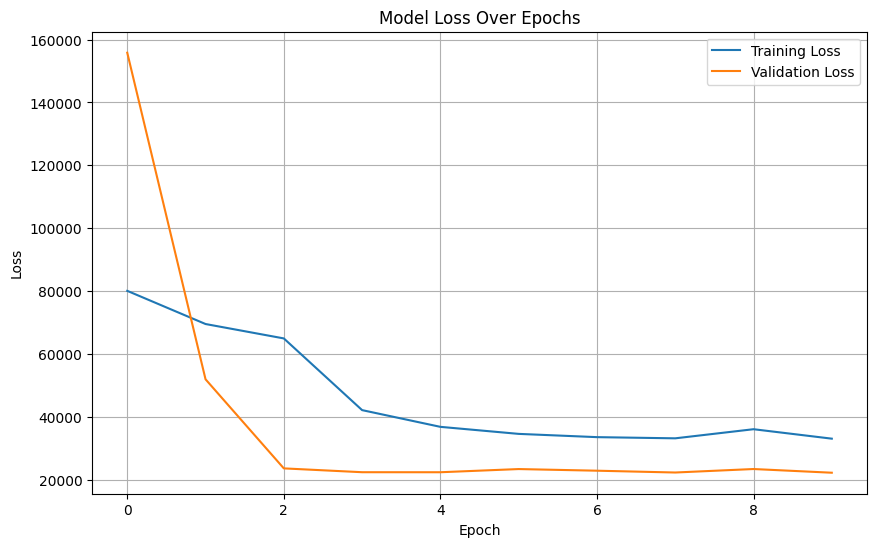

In [ ]:
# Plot the training and validation loss over epochs
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model Loss Over Epochs')
plt.legend()
plt.grid(True)
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
Test accuracy: 0.0000
Test weighted F1 score: 0.0000
Confusion matrix:


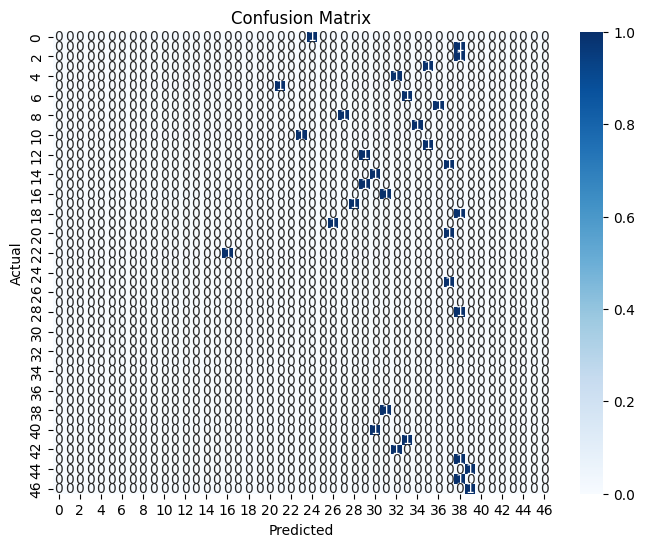

In [ ]:
# Evaluate the model on the test set and print accuracy, F1 score, and confusion matrix
# 
# Confusion matrix and F1 score are more meaningful for classification tasks, but since
# this is a regression task, we will convert the continuous outputs to discrete labels
# for evaluation purposes.

import matplotlib.pyplot as plt
import seaborn as sns

y_pred = model.predict([X_test_left, X_test_right]).flatten()

# convert regression outputs to discrete labels for accuracy / f1 / confusion matrix
y_test_cls = np.rint(y_test).astype(int)
y_pred_cls = np.rint(y_pred).astype(int)

acc = accuracy_score(y_test_cls, y_pred_cls)
f1 = f1_score(y_test_cls, y_pred_cls, average="weighted")
cm = confusion_matrix(y_test_cls, y_pred_cls)

print(f"Test accuracy: {acc:.4f}")
print(f"Test weighted F1 score: {f1:.4f}")
print("Confusion matrix:")

# Display the confusion matrix as a heatmap
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()